In [23]:
import pandas as pd
df=pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsOneClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [26]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [27]:
df.describe(include='object')

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


In [28]:
import warnings
warnings.filterwarnings('ignore')

Text(0.5, 1.0, 'Disturbtion of Obesity Levels')

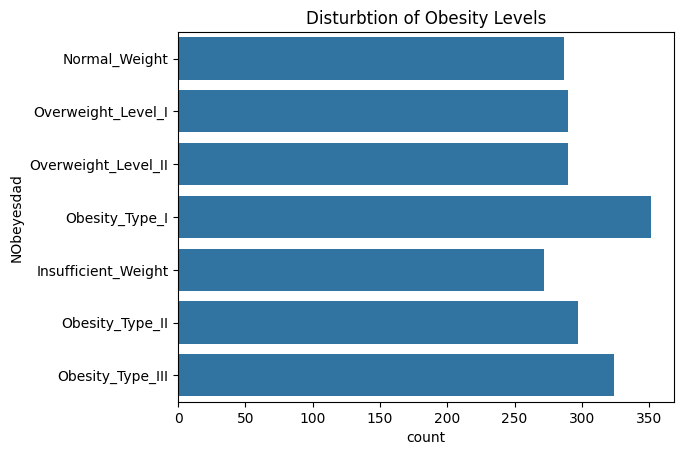

In [29]:
sns.countplot(df['NObeyesdad'] )
plt.title("Disturbtion of Obesity Levels")

In [30]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

<Axes: >

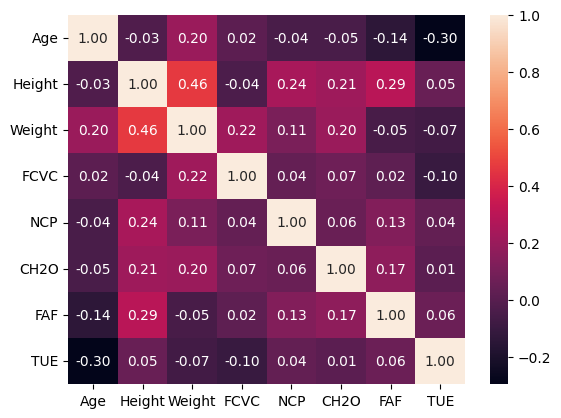

In [31]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, annot=True , fmt='.2f')

In [32]:
df.describe().columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='str')

In [33]:
continouts_col=['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
scaler=StandardScaler()
scaled_features=scaler.fit_transform(df[continouts_col])
scaled_df=pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continouts_col))
scaled_df.describe()
df_no_continouts=df.drop(columns=['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'])

In [35]:
df_scaled=pd.concat([scaled_df, df_no_continouts], axis=1)
df_scaled.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II


In [39]:
df_encoded=pd.get_dummies(data=df_scaled, columns=['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'], dtype=int)
df_scaled.shape , df_encoded.shape

((2111, 17), (2111, 32))

In [40]:
df.describe(include='object').columns

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

In [41]:
df_encoded.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Female,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,Normal_Weight,1,...,0,0,0,0,1,0,0,0,1,0
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,Normal_Weight,1,...,1,0,0,1,0,0,0,0,1,0
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,Normal_Weight,0,...,0,0,1,0,0,0,0,0,1,0
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,Overweight_Level_I,0,...,0,0,1,0,0,0,0,0,0,1
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,Overweight_Level_II,0,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].astype('category').cat.codes
df_encoded.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Female,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,1,1,...,0,0,0,0,1,0,0,0,1,0
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,1,1,...,1,0,0,1,0,0,0,0,1,0
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1,0,...,0,0,1,0,0,0,0,0,1,0
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,5,0,...,0,0,1,0,0,0,0,0,0,1
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,6,0,...,0,0,0,1,0,0,0,0,1,0


In [45]:
x=df_encoded.drop(columns=['NObeyesdad'])
y=df_encoded['NObeyesdad']
x.shape , y.shape

((2111, 31), (2111,))

In [46]:
x.sample(10)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
216,-0.206889,-1.089991,-0.900748,1.088342,0.404153,-0.013073,2.339750,-1.080625,1,0,...,0,0,0,1,0,0,0,0,0,1
1484,2.074104,-1.628012,-0.401129,-0.785019,0.102313,-0.745332,0.399467,-1.080625,1,0,...,0,0,0,1,0,1,0,0,0,0
279,-0.994977,0.946828,-1.320836,1.088342,0.404153,-0.013073,-0.012109,0.561997,0,1,...,0,0,0,1,0,0,0,0,1,0
1071,-0.546813,-1.936793,-0.744814,0.139387,0.404153,-0.257853,-0.065662,1.292195,1,0,...,0,0,0,0,1,0,0,0,1,0
1573,0.247641,0.701091,1.052019,-0.362143,0.404153,0.238761,0.301706,-0.439710,0,1,...,0,0,0,1,0,0,0,0,1,0
1741,0.621423,1.231414,1.302773,1.084503,0.404153,1.155083,-0.317991,0.516092,0,1,...,0,0,0,1,0,1,0,0,0,0
1556,-0.675366,-0.967418,0.633549,1.056573,-2.025665,-0.942493,-1.188039,1.696886,0,1,...,0,0,0,0,1,0,0,0,1,0
277,-0.522124,1.268431,-0.747989,-0.785019,1.689740,1.618759,2.339750,2.204618,0,1,...,0,0,0,1,0,0,0,0,0,1
590,-0.616687,-1.843357,-1.765998,0.532770,0.255640,-0.926961,-1.017968,-0.551196,1,0,...,0,0,0,1,0,0,0,0,1,0
1808,-0.473988,-0.072096,1.801746,1.088342,0.404153,-1.092953,1.077131,0.374960,1,0,...,0,0,0,1,0,0,0,0,1,0


In [47]:
x.columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE',
       'Gender_Female', 'Gender_Male', 'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes',
       'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no',
       'SMOKE_no', 'SMOKE_yes', 'SCC_no', 'SCC_yes', 'CALC_Always',
       'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile',
       'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation',
       'MTRANS_Walking'],
      dtype='str')

In [48]:
x_train , x_test, y_train , y_test= train_test_split(x,y, test_size=.2, random_state=42)
x_train.shape , x_test.shape, y_train.shape , y_test.shape

((1688, 31), (423, 31), (1688,), (423,))

In [53]:
lr=LogisticRegression( max_iter=1000)
lr.fit(x_train , y_train)
y_pred=lr.predict(x_test)
acc= accuracy_score(y_test, y_pred)
print(f"the accuracy score of one versus all multiclass model is {acc}")

the accuracy score of one versus all multiclass model is 0.8723404255319149


In [55]:
model_ovo=OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(x_train, y_train)
y_preds=model_ovo.predict(x_test)
acc= accuracy_score(y_test, y_preds)
print(f"the accuracy score of one verus one multiclass model is {acc}")

the accuracy score of one verus one multiclass model is 0.933806146572104


In [56]:
CR=classification_report(y_test , y_preds)
CR

'              precision    recall  f1-score   support\n\n           0       0.89      1.00      0.94        56\n           1       0.96      0.79      0.87        62\n           2       1.00      0.94      0.97        78\n           3       0.94      1.00      0.97        58\n           4       1.00      1.00      1.00        63\n           5       0.84      0.88      0.86        56\n           6       0.89      0.94      0.91        50\n\n    accuracy                           0.93       423\n   macro avg       0.93      0.93      0.93       423\nweighted avg       0.94      0.93      0.93       423\n'

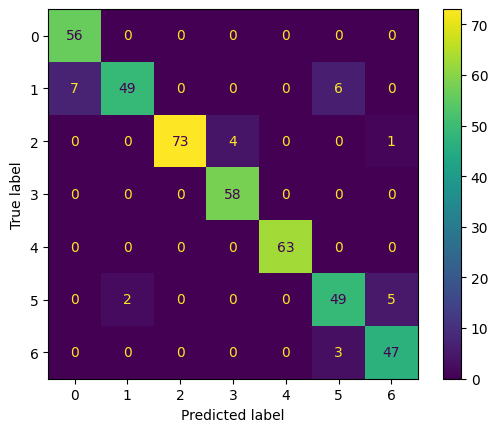

In [61]:
# LET'S Plot confusion matrix
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm=confusion_matrix(y_test, y_preds)
cmd=ConfusionMatrixDisplay(cm)
cmd.plot()